# BigQuery のデータを用いたビジネス分析 AI エージェント

このノートブックでは、BigQuery に保存された e-コマースサイトのビジネスデータを分析する AI エージェントを実装します。

特に、保存データの構造や利用方法をまとめた「ナレッジベース」を用いて、データ分析におけるハルシネーションを回避する方法を説明します。このナレッジベースは、一般に、データベースの「セマンティックレイヤー」に相当します。


## 事前準備

**[BAA-01]**

ADK と Gemini API の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

**最後に `RESTART SESSION` ボタンが表示された場合は、これをクリックしてセッションを再起動してください。**

**注意**: `ERROR: pip's dependency resolver does not currently take into account...` のようなエラーメッセージが表示される場合がありますが、これは無視して構いません。

In [ ]:
%pip install --upgrade --user \
    google-adk==2.8.0 \
    google-cloud-aiplatform==2.0.1 \
    google-cloud-dataplex==2.20.0 \
    google-genai==2.20.0 \
    vl-convert-python==1.9.0.post1 \
    pillow==12.3.0

**[BAA-02]**

インストールされたパッケージのバージョンを確認します。

In [ ]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform|google-cloud-dataplex|vl-convert-python|pillow)"

google-adk                            2.8.0
google-cloud-aiplatform               2.0.1
google-cloud-dataplex                 2.20.0
google-genai                          2.20.0
pillow                                12.3.0
vl-convert-python                     1.9.0.post1


下記の内容が出力されたことを確認してください。

```
google-adk                               2.8.0
google-cloud-aiplatform                  2.0.1
google-cloud-dataplex                    2.20.0
google-genai                             2.20.0
pillow                                   12.3.0
vl-convert-python                        1.9.0.post1
```

## ユーザー認証

**[BAA-03]**

変数 `PROJECT_ID` に事前に準備したプロジェクトのプロジェクト ID を指定してください。

**注意**: プロジェクトを作成したユーザーアカウントと Colab を使用中のユーザーアカウントが一致している必要があります。


In [ ]:
###
PROJECT_ID = 'Project ID を入力'
###

if (not PROJECT_ID) or PROJECT_ID == 'Project ID を入力':
    print('Gemini API を使用する Google Cloud Project の Project ID を入力してください。')
else:
    print(f'変数 PROJECT_ID を設定しました。')
    print(f'PROJECT_ID = {PROJECT_ID}')

**[BAA-04]**

Google Cloud のプロジェクトを使用するためのユーザー認証を行います。

ポップアップ画面の指示に従って、認証処理を行ってください。

許可する操作を選択するチェックボックスが表示された場合は、すべてにチェックを入れてください。

In [ ]:
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## 初期設定

**[BAA-05]**

この後の作業に必要なモジュールをインポートして、LlmAgent オブジェクトが参照する環境変数を設定します。あわせて、アーティファクトを保存するクラウドストレージのバケットを作成します。

In [ ]:
import base64, copy, json, io, os, re, urllib, uuid
import vl_convert as vlc
from PIL import Image
from IPython.display import Markdown, display
import agentplatform
from agentplatform.frameworks import AdkApp
from google import auth
from google import genai
from google.genai.types import (
    Content, GenerateContentConfig, HttpOptions, HttpRetryOptions,
    ImageConfig, Part, SafetySetting, ThinkingConfig, ThinkingLevel,
)
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.models.google_llm import Gemini
from google.adk.integrations.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.integrations.bigquery.config import BigQueryToolConfig, WriteMode
from google.adk.planners import BuiltInPlanner
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool

agentplatform.init(project=PROJECT_ID, location='us-central1')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l us-central1 gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


**[BAA-06]**

`bigquery_toolset` を用意します。これは、BigQuery のデータセットを検索するための次のツール群を提供します。

- list_dataset_ids: プロジェクト内に存在するデータセット ID を取得する
- get_dataset_info: データセットに関するメタデータを取得する
- list_table_ids: データセット内に存在するテーブル ID を取得する
- get_table_info: テーブルに関するメタデータを取得する
- execute_sql: SQL を実行し、結果を取得する
- ask_data_insights: 自然言語を使用して、テーブル内のデータに関する質問に回答する

In [ ]:
tool_config = BigQueryToolConfig(write_mode=WriteMode.BLOCKED)

application_default_credentials, _ = auth.default()
credentials_config = BigQueryCredentialsConfig(
    credentials=application_default_credentials
)

bigquery_toolset = BigQueryToolset(
    credentials_config=credentials_config,
    bigquery_tool_config=tool_config,
)

/root/.local/lib/python3.13/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.GOOGLE_CREDENTIALS_CONFIG is enabled.
  check_feature_enabled()


**[BAA-07]**

AdkApp オブジェクトとの会話を行う簡易的なアプリケーションのクラス ChatClient を定義します。

In [ ]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

**[BAA-08]**

「日本語テキスト出力時のマークダウン表示崩れの防止ルール」と Gemini API のモデル選択をテンプレートとして用意しておきます。

In [ ]:
markdown_rule = r'''
# 日本語テキスト出力時のマークダウン表示崩れの防止ルール
マークダウンの修飾記号（太字 `**` や斜体 `*` など）と、日本語の特殊記号や全角文字が隣り合うことで生じる表示崩れを防ぐため、以下のルールを厳守してください。

## 1. 記号と太字の間にスペースを入れる基本ルール
太字記号（`**`）の直前・直後に、鉤括弧や丸括弧、その他の記号が来る場合は、必ず半角スペースを1つ挟んでください。

- **全角鉤括弧（「」）：**
  - 【NG例】`**「重要」**なポイント`
  - 【OK例】`**「重要」** なポイント`
- **全角・半角の丸括弧（（） / ()）：**
  - 【NG例】`**（注意）**事項です`
  - 【OK例】`**（注意）** 事項です`
- **パーセント（% / ％）や数値・単位：**
  - 【NG例】`達成率は**100%**です`
  - 【OK例】`達成率は **100%** です`

## 2. 記号自体のエスケープと厳禁な組み合わせ
- マークダウンの特殊文字として誤認されやすい半角記号（`*`, `_`, `~`, `\` など）をそのまま表示する場合は、隣接するアスタリスク等との間にスペースを設けてください。
- アンダースコア（`_`）は単語の途中の日本語や全角文字と混ざると強力なイタリック・太字パーサに拾われやすいため、強調用以外では原則として直接隣接させないでください。

## 3. 通貨記号 `$` のエスケープ
- 通貨記号 `$` は数式の開始と誤認されないようにエスケープして出力してください。
  - 【NG例】`$100`
  - 【OK例】`\$100`
'''

flash_lite_model = Gemini(
    model='gemini-3.1-flash-lite',
    retry_options=HttpRetryOptions(),
)

flash_model = Gemini(
    model='gemini-3.8-flash',
    retry_options=HttpRetryOptions(),
)

planner = BuiltInPlanner(
    thinking_config=ThinkingConfig(
        thinking_level=ThinkingLevel.LOW,
        include_thoughts=False,
    ),
)

## グラフ画像を作成するツール関数

**[BAA-09]**

Vega-Lite の JSON テキストを受け取って、グラフ画像を作成・保存する関数を定義します。

In [ ]:
async def save_vega_chart_artifact(
    vl_spec_json: str, tool_context: ToolContext,
) -> str:
    """
    Vega-Lite の JSON 仕様を受け取り、PNG 画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-Lite の JSON 仕様文字列

    Returns:
        str: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """

    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=90)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        filename = f'{uuid.uuid4()}.png'
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

**[BAA-10]**

ツール関数 `save_vega_chart_artifact` を利用して、グラフ画像を作成する LlmAgent オブジェクト `chart_agent` を定義します。

`AgentTool(chart_agent)` でツール関数に変換すると、グラフ画像を作成するツール関数として利用できます。

In [ ]:
instruction='''
あなたはデータ可視化の専門家です。ユーザーからの依頼に応じて、次の手順でグラフ画像を作成します。
1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用する。
2. 生成した JSON 仕様を save_vega_chart_artifact で PNG 画像として保存する。
3. 作成したグラフのタイトルと保存したファイル名を次のフォーマットで出力する。
```
- title: <グラフのタイトル>
- filename: <ファイル名>
```
'''

chart_agent = LlmAgent(
    name='chart_agent',
    model=flash_lite_model,
    description='与えられたデータからグラフを作成する AI エージェント',
    instruction=instruction,
    tools=[save_vega_chart_artifact],
)

## ファイル名と画像ファイルデータを相互変換するコールバック関数

**[BAA-11]**

マークダウンテキスト内の `![<画像の説明>](<ファイル名>)`という部分を対応するアーティファクトを用いて、`![<画像の説明#ファイル名>](<base64 文字列>)` に置換する関数を定義します。

In [ ]:
async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'

    # find filenames in the markdown text.
    matches = list(re.finditer(pattern, markdown_text, flags=re.MULTILINE))
    if not matches:
        return markdown_text
    unique_filenames = {match.group(2) for match in matches}

    image_map = {}
    for filename in unique_filenames:
        print(f'## Converting `{filename}` into base64 string.', flush=True)
        image_artifact = await callback_context.load_artifact(filename=filename)
        image_bytes = image_artifact.inline_data.data

        # Resize and convert to jpeg image.
        with Image.open(io.BytesIO(image_bytes)) as img:
            if img.mode in ('RGBA', 'P'):
                img = img.convert('RGB')
            if max_width and img.width > max_width:
                ratio = max_width / img.width
                new_height = int(img.height * ratio)
                img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

            output_buffer = io.BytesIO()
            img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
            jpeg_data = output_buffer.getvalue()

        # Create filename to base64 string map.
        b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
        image_map[filename] = f'data:image/jpeg;base64,{b64_encoded}'

    def replacer(match):
        alt_text, filename = match.group(1), match.group(2)
        return f'![{alt_text}#{filename}]({image_map[filename]})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-12]**

関数 `replace_filename_with_base64` で大規模言語モデルの応答メッセージに含まれるファイル名を対応するアーティファクトの base64 文字列に置き換えて、インライン画像を用意するコールバック関数を定義します。

In [ ]:
async def callback_load_images(
    callback_context, llm_response,
):
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=800,
            callback_context=callback_context,
        )

    return None

**[BAA-13]**

マークダウンテキスト内の `![<画像の説明#ファイル名>](<base64 文字列>)` という部分を `![<画像の説明>](<ファイル名>)` に置換する関数を定義します。

In [ ]:
def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            filename = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        print(f'## Replacing base64 string with `{filename}`', flush=True)
        return f'![{clean_alt_text}]({filename})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-14]**

関数 `replace_base64_with_filename` で大規模言語モデルへの入力メッセージに含まれるインライン画像をファイル名に置き換えるコールバック関数を定義します。

In [ ]:
async def callback_remove_base64(
    callback_context, llm_request,
):
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

## ナレッジベースの作成

**[BAA-15]**

BigQuery のテーブルセットを分析して、ナレッジベースのベースラインを作成する AI エージェントを定義します。

In [ ]:
instruction = f'''
あなたは、後続の AI エージェントに向けた高度な**コンテキスト・ジェネレーター**です。
人間のためのレポートを作成するのではなく、後続エージェントが推論能力を最大限に発揮できるよう、自由な集計・絞り込みの基盤となる「統計的密度が高く、全期間を網羅したミクロデータ（明細レベル）のナレッジベース」を生成してください。

# 1. データ抽出とサンプリングの厳格な原則
後続エージェントの分析自由度を最大化するため、以下の原則を守ってデータを抽出してください。
- **ミクロデータ（明細レベル）の徹底**: 事前集計（マクロ・メゾレベルへの要約）は行わず、イベントやトランザクションの明細データを提供してください。これにより、後続エージェントが `WHERE` や `GROUP BY` を用いて多角的な分析を行えます。
- **時間軸の完全網羅**: SQLを実行する前に必ずテーブルの最小日と最大日を確認し、特定の期間（直近30日など）に偏らせず、データセットに存在する全期間を対象に含めてください。
- **サンプリングのランダム化**: レコード件数が上限（1,000件）を超える場合、単なる `LIMIT` ではなく `TABLESAMPLE SYSTEM (x PERCENT)` を用いた分散抽出を行い、全体の分布を維持した「代表データ」を取得してください。
- **「Top N」の禁止**: 「売上上位」などの偏ったフィルタリングは避けてください。低頻度だが重要な事象（ノイズ）が消し去られるのを防ぐためです。
- **リッチな結合（JOIN）の維持**: 中心となるトランザクションデータに対し、関連するマスタデータ（ユーザー属性、商品情報など）を適切に `JOIN` し、切り口となるカラムが豊富なベースクエリを作成してください。

# 2. セクションの選定方針（ビジネス視点ごとのミクロデータ）
1つの巨大なテーブルを作るのではなく、後続エージェントが分析目的に応じて使い分けられるよう、以下の**ビジネス視点ごとに最適化されたミクロデータのセクション**を生成してください。

1. **売上・商品分析用ミクロデータ**
  - **中心**: `order_items` に対して `products`（カテゴリ、ブランド、コストなど）と `orders`（ステータス、日時）を結合。
  - **目的**: 「カテゴリ別の利益率」や「ブランド別の売上トレンド」などを算出するための基盤。

2. **顧客プロファイリング用ミクロデータ**
  - **中心**: `users` に対して顧客の属性（年齢、性別、地域、トラフィックソース）と、初回購入日やLTV計算の基になるオーダー履歴情報を結合。
  - **目的**: 「年代別の購買行動」や「ロイヤルカスタマーの特定」を行うための基盤。

3. **物流・オペレーション用ミクロデータ**
  - **中心**: `orders` や `order_items` の各種タイムスタンプ（作成、出荷、配送、返品）に対して `distribution_centers` や `users` の位置情報を結合。
  - **目的**: 「配送センター別のリードタイム」や「地域別の遅延率・キャンセル率」を分析するための基盤。

4. **ユーザー行動（Webイベント）ミクロデータ**
  - **中心**: `events` に対してセッション情報、ブラウザ/OS情報、トラフィックソースを結合。
  - **目的**: 「コンバージョンファネルの分析」や「離脱ポイントの特定」を行うための基盤。

# 3. データ取得方法
bigquery_toolset を用いて以下の情報を参照してください。
- **対象データセット**: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- **実行環境**: BigQuery Job は `project id: {PROJECT_ID}` で実行すること。

# 4. 出力フォーマット（ナレッジベースの構成）
各ビジネス視点ごとにセクションを作成し、以下のMarkdown構造に厳密に沿って出力してください。
```markdown
# TheLook eCommerce データナレッジベース

## セクション番号：[ビジネス視点]のミクロデータ基盤
### データの説明
※ このベースデータを使って、後続エージェントがどのような分析（例：「カテゴリ別の売上推移」「地域別の返品率」など）を実行可能か、そのポテンシャルを記載すること。

### CSV データを取得するベース SQL
※ 実行可能な単一の SELECT 文。1,000件を超える場合はサンプリング済みの状態にすること。
※ 事前集計（GROUP BYによる要約）は原則行わず、明細行を維持すること。
※ 後続エージェントがこのクエリをサブクエリやCTE（WITH句）として扱い、外側から WHERE 句や GROUP BY 句を自由に追加して分析できる構成にすること。

### CSV データの全レコード件数（フィルタリング前）

### CSV データのサンプル
※ 最大20件。時系列の「最初・中間・最後」から抽出して提示すること。

### 統計的特徴、異常値、相関関係
※ サンプリングされたデータから読み取れる、後続エージェントの分析のヒントとなる特徴（特定の月の返品率のスパイクなど）を詳細に記載すること。

### その他の特筆項目

```

# 5. 最終出力要件
余分な挨拶や解説は一切含めず、**指定されたフォーマットに従ったナレッジベースのマークダウンテキストのみを出力**してください。

{markdown_rule}
'''
kb_generator_agent = LlmAgent(
    name='kb_generator_agent',
    model=flash_model,
    description='データ分析のナレッジベースを作成する AI エージェント',
    instruction=instruction,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    tools=[bigquery_toolset],
)

kb_generator_app = AdkApp(
    agent=kb_generator_agent,
    app_name='kb_generator_app',
)

**[BAA-16]**

ナレッジベースのベースラインを作成して、ファイル `knowledge_base.md` に保存します。

実際の運用では、ここで用意されたファイルをデータアナリストがチェックして、内容を修正・拡充したものを使用します。

In [ ]:
chat_client = ChatClient(kb_generator_app)

query = '''
利用可能なデータを確認した上でナレッジベースを作成。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

with open('knowledge_base.md', 'w') as f:
    f.write(response)

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
/root/.local/lib/python3.13/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.GOOGLE_TOOL is enabled.
  check_feature_enabled()
/root/.local/lib/python3.13/site-packages/google/adk/models/llm_request.py:298: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR

# TheLook eCommerce データナレッジベース

## セクション1：売上・商品分析のミクロデータ基盤
### データの説明
本ベースデータは、注文明細（`order_items`）を中心に、商品マスタ（`products`）および注文ヘッダ（`orders`）を結合したトランザクション明細レベルのミクロデータです。事前集計を行っていないため、後続エージェントは以下の分析を柔軟に実行可能です。
- **「商品カテゴリ別・ブランド別の売上高および粗利率の算出」** （`sale_price` と `cost` を用いた利益構造の多角分析）
- **「時系列（年・四半期・月別）の売上推移と成長率モデリング」**
- **「商品カテゴリ別の返品率・キャンセル率の差異要因分析」**
- **「性別（`user_gender`）やバスケットサイズ（`order_num_of_items`）と商品価格帯のクロス集計」**

### CSV データを取得するベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.inventory_item_id,
  oi.status AS item_status,
  oi.created_at AS item_created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  ROUND(oi.sale_price, 2) AS sale_price,
  p.name AS product_name,
  p.category AS product_category,
  p.brand AS product_brand,
  ROUND(p.cost, 2) AS product_cost,
  ROUND(p.retail_price, 2) AS product_retail_price,
  p.department AS product_department,
  p.distribution_center_id,
  o.status AS order_status,
  o.gender AS user_gender,
  o.num_of_item AS order_num_of_items
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi TABLESAMPLE SYSTEM (1 PERCENT)
JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
LIMIT 1000
```

### CSV データの全レコード件数（フィルタリング前）
181,694件

### CSV データのサンプル
```csv
order_item_id,order_id,user_id,product_id,inventory_item_id,item_status,item_created_at,shipped_at,delivered_at,returned_at,sale_price,product_name,product_category,product_brand,product_cost,product_retail_price,product_department,distribution_center_id,order_status,user_gender,order_num_of_items
21516,14877,11903,16946,58057,Shipped,2019-01-13 08:13:02 UTC,2019-01-13 21:57:26 UTC,,,38.0,Armani Exchange Blurred Logo Tee,Tops & Tees,A:X Armani Exchange,22.08,38.0,Men,8,Shipped,M,1
112816,77858,61910,15402,305085,Shipped,2019-01-16 15:26:29 UTC,2019-01-17 12:52:54 UTC,,,7.0,HUE Women's Argyle Knee Sock,Plus,HUE,3.67,7.0,Women,2,Shipped,F,3
171771,118524,94574,1021,464087,Shipped,2019-01-17 11:15:00 UTC,2019-01-18 03:23:45 UTC,,,46.22,Calvin Klein Jeans Women's Short Sleeve Cowl Neck Sweater,Sweaters,Calvin Klein Jeans,18.67,46.22,Women,8,Shipped,F,2
31366,21669,17238,10028,84674,Processing,2019-01-17 21:09:58 UTC,,,,23.9,Hatley Women Text Appeal Sleepshirt,Sleep & Lounge,Hatley,13.74,23.9,Women,2,Processing,F,2
171772,118524,94574,6538,464089,Shipped,2019-01-18 12:05:17 UTC,2019-01-18 03:23:45 UTC,,,25.0,WHAT GOES AROUND COMES AROUND Women's Mimi Shorts,Shorts,What Goes Around Comes Around,13.67,25.0,Women,10,Shipped,F,2
112815,77858,61910,926,305082,Shipped,2019-01-19 12:01:08 UTC,2019-01-17 12:52:54 UTC,,,26.99,US Polo Assn. Juniors Sweater With Big Pony,Sweaters,U.S. Polo Assn.,11.23,26.99,Women,7,Shipped,F,3
31365,21669,17238,162,84672,Processing,2019-01-19 20:06:24 UTC,,,,34.99,Patty Women Smart V Neck Ruched Long Sleeve Blouse Top,Tops & Tees,Patty,20.08,34.99,Women,1,Processing,F,2
56937,39287,31261,15037,153833,Returned,2025-04-28 01:06:25 UTC,2025-04-27 11:02:50 UTC,2025-04-29 11:27:50 UTC,2025-05-02 10:44:50 UTC,72.0,Ingrid & Isabel Hipster Bottom,Maternity,Ingrid & Isabel,30.02,72.0,Women,4,Returned,F,2
62492,43127,34377,22113,168855,Processing,2025-04-28 01:07:22 UTC,,,,37.72,Haggar Men's Herringbone Pleat Front Cuff Suit Separate Pant,Pants,Haggar,17.95,37.72,Men,6,Processing,M,1
85780,59275,47154,14618,231805,Shipped,2025-04-28 01:09:05 UTC,2025-04-24 20:12:50 UTC,,,45.0,A Pea in the Pod: Short Sleeve Pull Down Smocked Back Nursing Shirt,Maternity,A Pea in the Pod,17.96,45.0,Women,7,Shipped,F,2
53278,36802,29304,18707,143926,Shipped,2025-04-28 01:09:08 UTC,2025-04-30 21:10:10 UTC,,,20.0,Eurosocks Ski Zone Sock,Active,Eurosock,8.18,20.0,Men,2,Shipped,M,1
152993,105617,84178,21607,413346,Processing,2025-04-28 01:15:25 UTC,,,,158.0,Joe's Jeans The Rebel Malcom,Jeans,Joe's Jeans,89.9,158.0,Men,6,Processing,M,1
73399,50669,40344,3005,198305,Complete,2025-04-28 01:32:38 UTC,2025-05-01 01:42:45 UTC,2025-05-04 18:57:45 UTC,,46.0,Champion Women's Shape Too Bra,Active,Champion,18.45,46.0,Women,2,Complete,F,1
55082,38025,30274,25557,148785,Cancelled,2025-04-28 01:37:20 UTC,,,,25.0,Wolverine Men's Performance Base Layer Top,Underwear,Wolverine,10.8,25.0,Men,1,Cancelled,M,1
130207,89870,71540,4160,351910,Shipped,2026-09-19 22:23:59 UTC,2026-09-18 10:57:33 UTC,,,13.57,Allegra K Ladies Ruffled Decor Sleeveless Short Jumpsuit XS White,Jumpsuits & Rompers,Allegra K,6.69,13.57,Women,9,Shipped,F,3
129488,89368,71162,24697,349949,Cancelled,2026-09-19 22:55:19 UTC,,,,12.0,Carhartt Men's All Terrain Low Cut Tab Socks,Socks,Carhartt,6.91,12.0,Men,3,Cancelled,M,3
101967,70347,55963,26134,275465,Complete,2026-09-19 23:21:06 UTC,2026-09-16 01:26:16 UTC,2026-09-16 15:41:16 UTC,,25.0,Pull-In Men's Fashion Ikone 16 Boxer Brief,Underwear,Pull-in,12.53,25.0,Men,3,Complete,M,2
117736,81272,64642,23195,318285,Returned,2026-09-19 23:39:53 UTC,2026-09-16 15:05:20 UTC,2026-09-16 20:50:20 UTC,2026-09-18 14:01:20 UTC,42.99,Match Men's Retro BDU Multi-color Cargo Shorts #S3640,Shorts,Match,21.92,42.99,Men,2,Returned,M,2
106294,73359,58364,20692,287140,Complete,2026-09-19 23:47:27 UTC,2026-09-18 21:17:03 UTC,2026-09-23 16:42:03 UTC,,55.0,Lee Men's Big & Tall Premium Select Custom Fit Loose Straight Leg Jean,Jeans,Lee,29.86,55.0,Men,5,Complete,M,2
52028,35955,28626,22217,140562,Processing,2026-09-19 23:55:25 UTC,,,,109.5,Paul Fredrick 100% Wool Gabardine Wrinkle Stain Resistant Pleated Front Pant,Pants,Paul Fredrick,47.09,109.5,Men,5,Processing,M,4
103825,71637,56987,6100,280456,Processing,2026-09-19 23:57:12 UTC,,,,59.75,So Low Eclon High Impact Legging,Leggings,SOLOW,36.87,59.75,Women,5,Processing,F,4
```

### 統計的特徴、異常値、相関関係
- **対象期間と成長トレンド**: データは 2019-01-13 から 2026-09-19 までの約7年9ヶ月間を網羅しています。年間注文件数は 2019年の 1,575件から 2026年には 59,251件へと指数関数的に拡大しています。
- **価格および利益率の安定性**: 全体平均販売価格は 59.70 ドル（最小 0.02 ドル、最大 999.00 ドル）、平均原価は 28.69 ドル、平均粗利は 31.01 ドルです。粗利率は全期間を通じて約 **51.05%** で極めて安定して推移しています。
- **ステータス別構成比**:
  - `Shipped`: **29.86%**
  - `Complete`: **24.93%**
  - `Processing`: **20.15%**
  - `Cancelled`: **15.05%**
  - `Returned`: **10.01%**
- **返品率の一定性**: 年別の返品率は 2019年（**11.24%**）から 2025年（**9.80%**）、2026年（**10.09%**）と、年間を通じて約 **10%** 前後でほぼ固定された確率分布を示しています。
- **商品価格の極値（異常値・外れ値）**: 最小販売価格 0.02 ドル（アルミニウム製財布など）から、最大販売価格 999.00 ドル（高級コート等）まで幅広く分布しており、ロングテールな価格構造を持ちます。

### その他の特筆項目
- `products.retail_price` と `order_items.sale_price` は通常一致しますが、値引きやプロモーションキャンペーンを分析する際には差分を検証する余地があります。
- 同一注文（`order_id`）に複数商品が含まれる場合、各明細の `item_status` は注文全体の `order_status` と連動しますが、出荷日や返品日は明細単位で保持されます。

---

## セクション2：顧客プロファイリングのミクロデータ基盤
### データの説明
本ベースデータは、顧客マスタ（`users`）の全件を基軸とし、各顧客の初回購入日・最新購入日、累計注文件数、LTV（累積購買総額）、返品・キャンセル点数などの購買履歴サマリーを結合した顧客プロファイル明細データです。未購入ユーザー（LTVが0の行）も網羅されているため、後続エージェントは以下の分析を実行可能です。
- **「初回購入までのリードタイム分析と未購入ユーザーの離脱傾向分析」**
- **「年代別（`age`）・性別（`gender`）ごとの LTV 分布および優良顧客（ロイヤルカスタマー）セグメンテーション」**
- **「流入元（`traffic_source`）別のコンバージョン率および顧客獲得効率の評価」**
- **「居住国（`country`）・地域（`state`, `city`）別の顧客生涯価値の地理的比較」**

### CSV データを取得するベース SQL
```sql
WITH user_order_history AS (
  SELECT
    user_id,
    MIN(created_at) AS first_order_created_at,
    MAX(created_at) AS last_order_created_at,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(sale_price), 2) AS lifetime_value,
    COUNT(id) AS total_items_purchased,
    COUNTIF(status = 'Returned') AS total_items_returned,
    COUNTIF(status = 'Cancelled') AS total_items_cancelled
  FROM `bigquery-public-data.thelook_ecommerce.order_items`
  GROUP BY user_id
)
SELECT
  u.id AS user_id,
  u.first_name,
  u.last_name,
  u.email,
  u.age,
  u.gender,
  u.state,
  u.city,
  u.country,
  u.postal_code,
  u.traffic_source,
  u.created_at AS user_created_at,
  uo.first_order_created_at,
  uo.last_order_created_at,
  COALESCE(uo.total_orders, 0) AS total_orders,
  COALESCE(uo.lifetime_value, 0.0) AS lifetime_value,
  COALESCE(uo.total_items_purchased, 0) AS total_items_purchased,
  COALESCE(uo.total_items_returned, 0) AS total_items_returned,
  COALESCE(uo.total_items_cancelled, 0) AS total_items_cancelled
FROM `bigquery-public-data.thelook_ecommerce.users` AS u TABLESAMPLE SYSTEM (1 PERCENT)
LEFT JOIN user_order_history AS uo
  ON u.id = uo.user_id
LIMIT 1000
```

### CSV データの全レコード件数（フィルタリング前）
100,000件

### CSV データのサンプル
```csv
user_id,first_name,last_name,email,age,gender,state,city,country,postal_code,traffic_source,user_created_at,first_order_created_at,last_order_created_at,total_orders,lifetime_value,total_items_purchased,total_items_returned,total_items_cancelled
40953,Tyler,Ryan,tylerryan@example.com,56,M,Cataluña,Barcelona,Spain,8040,Organic,2019-01-02 00:36:00 UTC,2019-08-12 12:08:35 UTC,2023-03-30 09:26:54 UTC,3,306.51,7,0,1
11903,Hector,Murray,hectormurray@example.net,43,M,Henan,Huaihua,China,454991,Display,2019-01-02 00:37:00 UTC,2019-01-13 08:13:02 UTC,2019-06-26 13:54:55 UTC,2,62.0,2,0,1
18550,Willie,Hansen,williehansen@example.com,65,M,Florida,Palm Beach Gardens,United States,33410,Search,2019-01-02 00:44:00 UTC,,,,0,0.0,0,0,0
60920,Garrett,Baldwin,garrettbaldwin@example.org,64,M,England,London,United Kingdom,SW2,Search,2019-01-02 00:48:00 UTC,,,,0,0.0,0,0,0
94719,Michael,Jones,michaeljones@example.com,28,M,Fujian,Hefei,China,362299,Search,2019-01-02 00:54:00 UTC,2024-05-14 09:10:45 UTC,2024-05-14 09:10:45 UTC,1,30.0,1,0,0
48198,Jodi,Sosa,jodisosa@example.com,30,F,California,Wildomar,United States,92595,Search,2019-01-02 00:58:00 UTC,2023-11-18 18:50:46 UTC,2023-11-21 17:52:55 UTC,1,134.54,3,0,3
27077,Theresa,Carey,theresacarey@example.org,42,F,New South Wales,Wallangra,Australia,2360,Search,2019-01-02 01:32:00 UTC,2019-04-11 04:29:55 UTC,2019-04-12 04:19:58 UTC,1,94.94,2,0,0
54697,Keith,Adkins,keithadkins@example.com,37,M,Mississippi,Canton,United States,39046,Search,2022-12-12 12:20:00 UTC,2023-04-24 20:22:37 UTC,2023-09-28 00:14:57 UTC,2,326.78,6,0,0
91680,Shane,Santiago,shanesantiago@example.com,38,M,Gyeonggi-do,Bucheon City,South Korea,420-101,Organic,2022-12-12 12:44:00 UTC,2023-05-01 07:05:19 UTC,2025-08-02 10:38:39 UTC,2,257.25,5,2,0
48219,Sean,Barr,seanbarr@example.net,66,M,Hubei,Shenzhen,China,430081,Organic,2022-12-12 14:22:00 UTC,2026-05-02 17:45:05 UTC,2026-05-02 17:45:05 UTC,1,137.7,1,0,0
34344,Matthew,Shields,matthewshields@example.com,39,M,Shanxi,Foshan,China,30000,Search,2022-12-12 16:00:00 UTC,2023-01-01 03:47:11 UTC,2023-01-01 03:47:11 UTC,1,32.4,1,0,0
17601,Candice,Maldonado,candicemaldonado@example.com,14,F,Queensland,Albion,Australia,4010,Search,2022-12-12 16:15:00 UTC,2024-06-27 09:46:00 UTC,2024-06-27 10:13:43 UTC,1,139.98,2,0,0
54696,Cindy,Williams,cindywilliams@example.net,24,F,Tianjin,Chengdu,China,300240,Search,2022-12-12 16:29:00 UTC,2026-04-04 19:41:18 UTC,2026-04-04 19:41:18 UTC,1,39.99,1,0,0
67489,Kelly,Johnson,kellyjohnson@example.org,55,F,Rio de Janeiro,Duque de Caxias,Brasil,25213-005,Organic,2022-12-12 16:29:00 UTC,2024-12-05 12:45:14 UTC,2024-12-05 12:45:14 UTC,1,25.0,1,1,0
80985,Todd,Brown,toddbrown@example.org,22,M,Rio de Janeiro,Duque de Caxias,Brasil,25040-004,Search,2026-09-15 19:24:51 UTC,2026-09-16 18:38:19 UTC,2026-09-19 18:05:51 UTC,1,60.0,3,0,0
89794,Willie,Powers,williepowers@example.com,66,M,Incheon Metropolitan City,Incheon Metropolitan City,South Korea,404-170,Search,2026-09-15 19:26:05 UTC,2026-09-15 22:46:35 UTC,2026-09-15 22:46:35 UTC,1,286.0,1,0,0
64100,Susan,Coleman,susancoleman@example.net,47,F,Guangxi Zhuang Autonomous Region,Xiamen,China,537500,Search,2026-09-15 19:30:40 UTC,2026-09-15 18:19:53 UTC,2026-09-16 23:28:18 UTC,2,180.47,3,1,0
76428,Melinda,Stephens,melindastephens@example.com,27,F,Connecticut,Danbury,United States,6810,Search,2026-09-15 19:33:13 UTC,,,,0,0.0,0,0,0
73557,Brandi,Jones,brandijones@example.org,54,F,Pará,Marituba,Brasil,67105-290,Organic,2026-09-15 19:35:10 UTC,2026-09-15 20:40:21 UTC,2026-09-15 20:40:21 UTC,1,25.99,1,0,0
90553,Andrea,Hernandez,andreahernandez@example.org,37,F,Maranhão,Paço do Lumiar,Brasil,65060-000,Organic,2026-09-15 19:45:22 UTC,2026-09-16 19:56:18 UTC,2026-09-17 18:56:33 UTC,1,83.45,2,0,0
96622,Sarah,Davis,sarahdavis@example.org,36,F,California,Downey,United States,90240,Display,2026-09-15 19:46:36 UTC,2026-09-15 20:17:07 UTC,2026-09-15 20:17:07 UTC,1,16.5,1,0,0
```

### 統計的特徴、異常値、相関関係
- **顧客基盤とコンバージョン率**: 全ユーザー数 100,000人のうち、購買経験のあるユーザーは 79,984人（**79.98%**）、未購入ユーザーは 20,016人（**20.02%**）です。流入経路や登録時期に関わらず、約8割のユーザーが最終的に購買に至る特徴があります。
- **年齢層と性別分布**: 年齢は 12歳から 70歳まで一様に分布しており、平均年齢は **40.98歳** です。性別比率は男性・女性でほぼ 50:50 です。
- **LTV（累積購買総額）の分布**: 購買ユーザーの平均 LTV は **135.61 ドル**、最大 LTV は **1,886.50 ドル** です。購買ユーザーの平均注文回数は **1.57回** であり、最大注文件数は 4回に制限されています（リピート回数に上限キャップが存在するデータセット特性）。
- **トラフィックソース別の購買力**:
  - `Search`: 70,135人（購買率 **80.04%**、平均LTV **135.06 ドル**）
  - `Organic`: 14,977人（購買率 **79.72%**、平均LTV **134.82 ドル**）
  - `Facebook`: 5,889人（購買率 **79.44%**、平均LTV **137.55 ドル**）
  - `Email`: 5,172人（購買率 **80.78%**、平均LTV **141.49 ドル**）
  - `Display`: 3,827人（購買率 **79.80%**、平均LTV **137.93 ドル**）
  - 全流入経路の中で **`Email` 経由の顧客がコンバージョン率・平均 LTV ともに最も高い** 傾向を示します。

### その他の特筆項目
- ユーザー登録日（`user_created_at`）よりも初回注文日（`first_order_created_at`）が数時間先行しているケースが一部存在します（ゲスト購入後にアカウント作成されたシナリオ、またはデータ生成時のタイムスタンプ付与順のアーティファクト）。

---

## セクション3：物流・オペレーションのミクロデータ基盤
### データの説明
本ベースデータは、注文明細（`order_items`）における各タイムスタンプ（作成・出荷・配達・返品）に対し、出荷元拠点（`distribution_centers`）および配達先顧客（`users`）の地理情報（緯度経度、都市、国）を結合した物流オペレーションのミクロデータです。事前集計を行っていないため、後続エージェントは以下の分析を実行可能です。
- **「出荷リードタイム、輸送日数、合計フルフィルメント日数の各工程ボトルネック分析」**
- **「配送センター（DC）別の処理遅延率・キャンセル率・返品率の比較」**
- **「配送センターと配送先顧客間の直線輸送距離（`distance_km`）と輸送リードタイムの相関分析」**
- **「国別・地域別の国際配送オペレーション効率および配送遅延の特定」**

### CSV データを取得するベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.status AS item_status,
  oi.created_at AS order_created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  ROUND(TIMESTAMP_DIFF(oi.shipped_at, oi.created_at, HOUR) / 24.0, 2) AS shipping_lead_time_days,
  ROUND(TIMESTAMP_DIFF(oi.delivered_at, oi.shipped_at, HOUR) / 24.0, 2) AS delivery_transit_days,
  ROUND(TIMESTAMP_DIFF(oi.delivered_at, oi.created_at, HOUR) / 24.0, 2) AS total_fulfillment_days,
  ROUND(TIMESTAMP_DIFF(oi.returned_at, oi.delivered_at, HOUR) / 24.0, 2) AS return_lead_time_days,
  dc.id AS dc_id,
  dc.name AS dc_name,
  dc.latitude AS dc_latitude,
  dc.longitude AS dc_longitude,
  u.country AS user_country,
  u.state AS user_state,
  u.city AS user_city,
  u.postal_code AS user_postal_code,
  u.latitude AS user_latitude,
  u.longitude AS user_longitude,
  ROUND(ST_DISTANCE(ST_GEOGPOINT(dc.longitude, dc.latitude), ST_GEOGPOINT(u.longitude, u.latitude)) / 1000.0, 1) AS distance_km
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi TABLESAMPLE SYSTEM (1 PERCENT)
JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` AS dc
  ON p.distribution_center_id = dc.id
JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON oi.user_id = u.id
LIMIT 1000
```

### CSV データの全レコード件数（フィルタリング前）
181,694件

### CSV データのサンプル
```csv
order_item_id,order_id,user_id,item_status,order_created_at,shipped_at,delivered_at,returned_at,shipping_lead_time_days,delivery_transit_days,total_fulfillment_days,return_lead_time_days,dc_id,dc_name,dc_latitude,dc_longitude,user_country,user_state,user_city,user_postal_code,user_latitude,user_longitude,distance_km
21516,14877,11903,Shipped,2019-01-13 08:13:02 UTC,2019-01-13 21:57:26 UTC,,,0.54,,,8,Mobile AL,30.6944,-88.0431,China,Henan,Huaihua,454991,35.07474002,113.2632659,12369.6
112816,77858,61910,Shipped,2019-01-16 15:26:29 UTC,2019-01-17 12:52:54 UTC,,,0.88,,,2,Chicago IL,41.8369,-87.6847,United States,Florida,Clearwater,33755,27.98075312,-82.78228853,1603.5
171771,118524,94574,Shipped,2019-01-17 11:15:00 UTC,2019-01-18 03:23:45 UTC,,,0.67,,,8,Mobile AL,30.6944,-88.0431,United Kingdom,England,Manchester,M9,53.52470893,-2.212729892,7050.7
31366,21669,17238,Processing,2019-01-17 21:09:58 UTC,,,,,2,Chicago IL,41.8369,-87.6847,China,Sichuan,Baotou,610091,30.67957451,103.9878891,11863.3
171772,118524,94574,Shipped,2019-01-18 12:05:17 UTC,2019-01-18 03:23:45 UTC,,,-0.33,,,10,Savannah GA,32.0167,-81.1167,United Kingdom,England,Manchester,M9,53.52470893,-2.212729892,6498.8
112815,77858,61910,Shipped,2019-01-19 12:01:08 UTC,2019-01-17 12:52:54 UTC,,,-1.96,,,7,Philadelphia PA,39.95,-75.1667,United States,Florida,Clearwater,33755,27.98075312,-82.78228853,1503.4
31365,21669,17238,Processing,2019-01-19 20:06:24 UTC,,,,,1,Memphis TN,35.1174,-89.9711,China,Sichuan,Baotou,610091,30.67957451,103.9878891,12554.4
56937,39287,31261,Returned,2025-04-28 01:06:25 UTC,2025-04-27 11:02:50 UTC,2025-04-29 11:27:50 UTC,2025-05-02 10:44:50 UTC,-0.58,2.0,1.42,2.96,4,Los Angeles CA,34.05,-118.25,Brasil,São Paulo,São Paulo,02675-031,-23.47256155,-46.74656621,9892.3
62492,43127,34377,Processing,2025-04-28 01:07:22 UTC,,,,,6,Port Authority of New York/New Jersey NY/NJ,40.634,-73.7834,United States,Ohio,Maumee,43537,41.57438349,-83.68529845,835.7
85780,59275,47154,Shipped,2025-04-28 01:09:05 UTC,2025-04-24 20:12:50 UTC,,,-3.17,,,7,Philadelphia PA,39.95,-75.1667,Brasil,Piauí,Picos,64600-000,-7.128859417,-41.52334039,6270.0
53278,36802,29304,Shipped,2025-04-28 01:09:08 UTC,2025-04-30 21:10:10 UTC,,,2.83,,,2,Chicago IL,41.8369,-87.6847,China,Guangdong,Yueyang,518103,22.67470023,113.8095484,12508.3
152993,105617,84178,Processing,2025-04-28 01:15:25 UTC,,,,,6,Port Authority of New York/New Jersey NY/NJ,40.634,-73.7834,Brasil,Rio de Janeiro,Rio de Janeiro,21831,-22.89803287,-43.48443678,7728.1
73399,50669,40344,Complete,2025-04-28 01:32:38 UTC,2025-05-01 01:42:45 UTC,2025-05-04 18:57:45 UTC,,3.0,3.71,6.71,,2,Chicago IL,41.8369,-87.6847,United States,Colorado,Colorado Springs,80915,38.86940414,-104.6832628,1475.1
55082,38025,30274,Cancelled,2025-04-28 01:37:20 UTC,,,,,1,Memphis TN,35.1174,-89.9711,Germany,Baden-Württemberg,Ettlingen,76275,48.92727991,8.405874454,7692.9
130207,89870,71540,Shipped,2026-09-19 22:23:59 UTC,2026-09-18 10:57:33 UTC,,,-1.46,,,9,Charleston SC,32.7833,-79.9333,United States,Rhode Island,Johnston,2919,41.827375,-71.52009362,1249.6
129488,89368,71162,Cancelled,2026-09-19 22:55:19 UTC,,,,,3,Houston TX,29.7604,-95.3698,China,Henan,Tianjin,450002,34.78911751,113.6612707,12218.8
101967,70347,55963,Complete,2026-09-19 23:21:06 UTC,2026-09-16 01:26:16 UTC,2026-09-16 15:41:16 UTC,,-3.88,0.58,-3.29,,3,Houston TX,29.7604,-95.3698,United States,Connecticut,New Britain,6053,41.69022625,-72.78868143,2420.3
117736,81272,64642,Returned,2026-09-19 23:39:53 UTC,2026-09-16 15:05:20 UTC,2026-09-16 20:50:20 UTC,2026-09-18 14:01:20 UTC,-3.33,0.21,-3.08,1.71,2,Chicago IL,41.8369,-87.6847,United States,California,Merced,95348,37.40324763,-120.4990666,2835.8
106294,73359,58364,Complete,2026-09-19 23:47:27 UTC,2026-09-18 21:17:03 UTC,2026-09-23 16:42:03 UTC,,-1.08,4.79,3.67,,5,New Orleans LA,29.95,-90.0667,China,Inner Mongolia Autonomous Region,Shan Tou,15002,40.74166584,107.4068469,11951.2
52028,35955,28626,Processing,2026-09-19 23:55:25 UTC,,,,,5,New Orleans LA,29.95,-90.0667,Brasil,Espírito Santo,Serra,29171,-20.14387865,-40.24506074,7709.8
103825,71637,56987,Processing,2026-09-19 23:57:12 UTC,,,,,5,New Orleans LA,29.95,-90.0667,China,Shandong,Huzhou,266021,36.09534371,120.3544683,12013.1
```

### 統計的特徴、異常値、相関関係
- **配送センター別の規模**: 全米10箇所のディストリビューションセンターが存在し、上位拠点はメンフィス（24,286件）、シカゴ（24,186件）、ヒューストン（22,487件）です。拠点ごとのキャンセル率は **14.6% 〜 15.3%**、返品率は **9.3% 〜 10.3%** と極めて均一です。
- **標準リードタイム**:
  - 出荷リードタイム（作成から出荷）: 平均 **0.53日**（約12.7時間）
  - 配送輸送リードタイム（出荷から配達）: 平均 **2.48日**（約59.5時間）
  - 総合フルフィルメント所要日数: 平均 **3.01日**（約72.3時間）
  - 返品リードタイム（配達から返品完了）: 平均 **1.49日**（約35.8時間）
- **重大な異常値（合成データアーティファクト）**: 出荷済みレコード 117,746件中、**35,585件（約 30.2%）において `shipped_at < created_at` となる「マイナスの出荷リードタイム」が発生しています**。一方で、`delivered_at < shipped_at` や `returned_at < delivered_at` となる時系列逆転は 0件です。後続エージェントが実態リードタイム分析を行う際は、`shipped_at >= created_at` の条件絞り込み、または同一注文（`orders`）全体のタイムスタンプとの突合検証が必要です。
- **配送距離とリードタイムの相関**: すべての DC が米国内に位置する一方、顧客は中国・ブラジル・欧州など世界16カ国に分散しており、直線距離（`distance_km`）は数千 km から最大 18,000 km に達します。しかし、輸送日数（`delivery_transit_days`）は距離に関わらず概ね 2〜4日程度で完了しており、現実の長距離国際航空便輸送をシミュレートしたリードタイム設定となっています。

### その他の特筆項目
- `orders` テーブルの `shipped_at` と `order_items` の `shipped_at` には一部ミリ秒・秒単位の微小な差異が存在するため、明細単位の出荷日時を分析基準とすることが推奨されます。

---

## セクション4：ユーザー行動（Webイベント）のミクロデータ基盤
### データの説明
本ベースデータは、Web サイト上での全行動ログ（`events`）を中核とし、顧客情報（`users`）を結合したクリックストリームのミクロデータです。事前集計を行っていないため、後続エージェントは以下の分析を実行可能です。
- **「コンバージョンファネル分析」** （`home` → `department` → `product` → `cart` → `purchase` の遷移率およびボトルネック特定）
- **「カート放棄率（Cart Abandonment Rate）およびセッション途中離脱ポイントの特定」**
- **「ブラウザ環境（`browser`）や流入チャネル（`traffic_source`）ごとの購買到達率の比較」**
- **「匿名セッション（`user_id` が NULL）から会員ログイン・初回購入に至る行動パターンのトラッキング」**

### CSV データを取得するベース SQL
```sql
SELECT
  e.id AS event_id,
  e.session_id,
  e.sequence_number,
  e.user_id,
  e.created_at AS event_created_at,
  e.ip_address,
  e.city,
  e.state,
  e.postal_code,
  e.browser,
  e.traffic_source,
  e.uri,
  e.event_type,
  u.gender AS user_gender,
  u.age AS user_age
FROM `bigquery-public-data.thelook_ecommerce.events` AS e TABLESAMPLE SYSTEM (1 PERCENT)
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON e.user_id = u.id
LIMIT 1000
```

### CSV データの全レコード件数（フィルタリング前）
2,425,023件

### CSV データのサンプル
```csv
event_id,session_id,sequence_number,user_id,event_created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,user_gender,user_age
2374660,19035cbf-4144-49e4-83a4-97b7aece97b9,1,,2019-01-02 00:16:00 UTC,155.199.210.76,Shanghai,Hunan,411131,IE,YouTube,/department/women/category/leggings/brand/dapperworld,department,,
2328027,e67e41b3-5f65-46e6-b3e8-bedd9e161123,1,,2019-01-02 00:17:00 UTC,14.244.246.78,El Paso,Texas,79905,Chrome,Organic,/product/28271,product,,
1452066,eda069fb-5856-4766-8aff-223a3e69d6c9,1,,2019-01-02 00:25:00 UTC,4.183.202.160,Nanjing,Hubei,430071,Chrome,Email,/department/men/category/socks/brand/goldtoe,department,,
2374661,19035cbf-4144-49e4-83a4-97b7aece97b9,2,,2019-01-02 00:36:00 UTC,155.199.210.76,Shanghai,Hunan,411131,IE,YouTube,/product/6224,product,,
2328028,e67e41b3-5f65-46e6-b3e8-bedd9e161123,2,,2019-01-02 00:37:00 UTC,14.244.246.78,El Paso,Texas,79905,Chrome,Organic,/cart,cart,,
1483248,9340a664-7a3f-4164-99bc-12976a19c4af,1,,2019-01-02 00:44:00 UTC,217.21.108.6,Manheim,Pennsylvania,17545,Chrome,YouTube,/product/7236,product,,
2333172,cb80aaef-e48a-4c06-9f91-616cfb8ee088,1,,2019-01-02 00:45:00 UTC,153.51.203.156,Yokohama City,Kanagawa,225-0011,Chrome,Adwords,/department/women/category/sweaters/brand/tommyhilfiger,department,,
1557698,e7486efa-8843-4f35-ac2e-4d0a11bac3ed,1,,2024-05-15 10:39:00 UTC,175.213.68.42,Suzhou,Guangdong,523710,Chrome,Email,/product/3080,product,,
1993859,bb044794-a9ec-4026-9c30-7aa7cb030b41,1,,2024-05-15 10:39:00 UTC,216.238.205.135,Bucheon City,Gyeonggi-do,420-020,Chrome,Facebook,/product/930,product,,
757519,0abf7aa2-8d1d-4dd2-a998-457e2a87bcd4,4,58031,2024-05-15 10:40:32 UTC,95.224.131.2,Yulin,Shandong,277599,Chrome,Email,/cart,cart,F,66
757520,0abf7aa2-8d1d-4dd2-a998-457e2a87bcd4,5,58031,2024-05-15 10:40:38 UTC,95.224.131.2,Yulin,Shandong,277599,Chrome,Email,/purchase,purchase,F,66
2253375,64986726-373d-4bea-a46c-7b4681db6417,2,,2024-05-15 10:41:00 UTC,176.186.244.191,Yongzhou,Yunnan,654200,Chrome,Organic,/product/1613,product,,
1447538,1a2f9c8e-d251-446a-aaea-4f7f866c10f6,3,,2024-05-15 10:49:00 UTC,101.82.212.49,Taiyuan,Hebei,66104,Chrome,Adwords,/cancel,cancel,,
932745,70fd0783-5d9e-4d54-a66a-31bb9aca3262,10,71540,2026-09-19 22:23:59 UTC,179.188.105.69,Johnston,Rhode Island,2919,Other,Email,/purchase,purchase,F,15
927680,ed248c12-bee3-47d6-839d-f77badd417f2,10,71162,2026-09-19 22:55:19 UTC,160.1.223.77,Tianjin,Henan,450002,Chrome,YouTube,/purchase,purchase,M,64
730913,0bbd724e-840c-43f1-a498-4555a277b320,7,55963,2026-09-19 23:21:06 UTC,55.175.177.98,New Britain,Connecticut,6053,Chrome,Adwords,/purchase,purchase,M,42
843446,bde645db-1bed-4147-ac20-d11d9102cd89,7,64642,2026-09-19 23:39:53 UTC,134.172.69.90,Merced,California,95348,Chrome,Email,/purchase,purchase,M,43
761563,e7034e98-2f06-4846-b9e1-840f5b917e6f,7,58364,2026-09-19 23:47:27 UTC,104.157.199.11,Shan Tou,Inner Mongolia Autonomous Region,15002,Safari,Email,/purchase,purchase,M,62
372717,7e9a2d6d-2e93-4700-b147-3850cb382f34,13,28626,2026-09-19 23:55:25 UTC,63.139.207.7,Serra,Espírito Santo,29171,Chrome,Email,/purchase,purchase,M,33
744108,9f1e9237-469c-46fe-bd25-5cffc70c4e95,13,56987,2026-09-19 23:57:12 UTC,28.102.84.67,Huzhou,Shandong,266021,Safari,Adwords,/purchase,purchase,F,27
```

### 統計的特徴、異常値、相関関係
- **イベント総量とセッション構造**: イベント総件数は 2,425,023件、ユニークセッション数は 681,694セッション、ユニークユーザー数は 79,984人です。
- **イベントタイプの構成比**:
  - `product`（商品閲覧）: 843,858件（**34.80%**）
  - `department`（部門・カテゴリ閲覧）: 593,755件（**24.48%**）
  - `cart`（カート投入・閲覧）: 593,257件（**24.46%**）
  - `purchase`（購入完了）: 181,694件（**7.49%**）
  - `cancel`（キャンセル離脱）: 124,706件（**5.14%**）
  - `home`（トップページ閲覧）: 87,753件（**3.62%**）
- **ファネル転換率の指標**:
  - 全 681,694 セッションのうち、最終的に `purchase` に至ったセッションは 181,694件（コンバージョン率 **26.65%**）です。これは `order_items` の総件数（181,694件）と完全に 1:1 で一致しています。
  - セッションの途中で `cancel` に至ったセッションは 124,706件（**18.29%**）存在します。
- **ユーザー識別と匿名性**: イベント全体の **46.35%**（1,124,002件）は `user_id` が NULL の匿名状態です。これは閲覧段階では匿名でトラッキングされ、`cart` や `purchase` のコンバージョンステップにおいて会員情報（`user_id`）が付与される設計となっています。
- **ブラウザ・チャネルの偏り**: ブラウザは Chrome が約 **64%** を占め、次いで Safari（約 **15%**）、Firefox（約 **15%**）、IE（約 **5%**）です。流入チャネルは Email と Adwords が上位の大半を占めています。

### その他の特筆項目
- `sequence_number` はセッション内のアクション順序を示し、通常 1 から順にインクリメントされます。購入に至ったセッションは平均 5〜13 ステップの遷移を経て完了しています。
- URI パス（`/department/...`, `/product/...`, `/cart`, `/purchase`）を文字列パースすることで、閲覧された個別商品 ID やカテゴリ情報を抽出可能です。

## データ分析 AI エージェントの作成

**[BAA-17]**

ナレッジベースがアーティファクトに保存されているかチェックする before_agentコールバックを用意します。

In [ ]:
async def kb_check_callback(callback_context):
    kb_file = 'user:knowledge_base.md'
    reject_message = f'''
**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `{kb_file}` でアップロードしてください。
'''
    artifacts = await callback_context.list_artifacts()
    if kb_file not in artifacts:
        return Content(
            parts=[Part.from_text(text=reject_message)],
            role='model',
        )
    return None

**[BAA-18]**

これまでに用意したツール関数、コールバック関数などを用いて、データ分析 AI エージェントを定義します。

In [ ]:
instruction = f'''
あなたは、TheLook eCommerce 専任の**シニア・ビジネスコンサルタント**です。
"# ナレッジベースのコンテンツ" セクションに含まれるナレッジベース（KB）には、事前集計されていない「リッチな次元が結合された明細データ（ミクロデータ）」を取得するためのベース SQL がビジネス視点ごとに定義されています。
あなたはこの KB を「信頼できるデータ基盤（セマンティックレイヤー）」として活用し、ユーザーの課題に対してデータ駆動型の戦略的な分析を提供します。

# 1. 分析の基本サイクル（トップダウン・アプローチ）

KB のデータは明細レベルです。そのまま全件取得するのではなく、**必ずマクロな集計から入り、徐々にミクロな要因へとドリルダウンする**アプローチを徹底してください。

1. **KBの読み込み**: 課題解決に直結するミクロデータのセクション（ベース SQL）を特定します。
2. **実行計画の明示（必須）**: ツールを実行する**前**に、後述の【実行計画フォーマット】を用いてアプローチを宣言します（宣言後、ユーザーの返答を待たずに自律的にSQLを実行して構いません）。
3. **動的な集計とドリルダウンの実行**:

* **マクロ把握**: KB のベース SQL をサブクエリや CTE（WITH句）として扱い、外側で `GROUP BY` を行って全体トレンドを把握します。
* **メゾ・ミクロへの深掘り**: 全体像から特異点（急な売上低下、異常値など）を見つけたら、ベース SQL に `WHERE` 句を追加して対象を絞り込み、詳細な粒度で再集計、あるいは少量の明細データをサンプリング取得して要因を特定します。

4. **仮説と検証**: 分析結果から異常値や傾向を見つけたら、「なぜそうなったか」の仮説を立て、別の切り口での集計や別のベース SQL を用いてその仮説を裏付けます。

# 2. 【絶対ルール】ツール実行前の計画フォーマット

データ取得ツールを呼び出す直前に、**必ず以下のマークダウン形式で計画を出力**してください。このプロセスの省略は厳禁です。

```markdown
### 分析アプローチ
- **検証する仮説**: [データから何を明らかにするか]
- **使用するKBセクション**: [ベースとするKBのセクション名]
- **データ抽出・集計方針**: [どのような期間・条件で絞り込み、どのような粒度で集計するか ※SQLそのものの提示は不要]

```

*(※このブロックを出力した直後に、自律的にツールを実行してください)*

# 3. SQL 実行の権限と制約

* **高度なクエリ操作の許可**: KB のベース SQL は「素材」です。あなたの裁量でベース SQL を CTE で囲み、集計関数（SUM, AVG, COUNT等）、ウィンドウ関数、時間粒度の変更（DATE_TRUNC）、フィルタリング（WHERE, HAVING）を自由かつ積極的に適用してください。
* **新規クエリの制限**: KB のベース SQL に含まれないテーブル結合や、複雑な新ロジックが必要な場合に限り、事前に SQL を提示してユーザーの許可を得てください。
* **生データの大量取得禁止**: 意味のない「明細データの全件取得（例: LIMIT 1000）」は厳禁です。明細を取得する場合は、事前の集計分析に基づき `WHERE` で強力に絞り込み、原因究明に必要な範囲（数十件程度）に留めてください。

# 4. 分析・レポートの品質基準

* **事実と解釈の厳密な分離**:
* **【事実】**: 実行した SQL の集計結果やグラフから読み取れる客観的な数値・傾向。
* **【解釈】**: コンサルタントとしての洞察、背景の推測、および推奨アクション。


* **「想像」の排除**: 取得したデータのみを根拠とします。不足データがある場合は「不明」と明記し、取得のための提案を行ってください。
* **可視化の優先**: 時系列推移、構成比、相関関係など、比較が必要な箇所では必ず `chart_agent` を使用して視覚化してください。

# 5. ツール仕様とグラフの出力形式

* **データ取得設定**: `bigquery_toolset` を使用。
* Project ID: `bigquery-public-data` / Dataset: `thelook_ecommerce`
* BigQuery Job 実行 Project ID: `{PROJECT_ID}`


* *データ取得後の「データをありがとうございます」等の挨拶は不要です。即座に分析結果の報告へ移行してください。*
* **グラフの表示方法**: chart_agent はグラフのタイトルとファイル名（`<UUID>.png`）を返却します。グラフを表示する際は、必ず前後に空行を設け、以下のフォーマットを挿入してください（フロントエンドがこれを検知して描画します）。

```markdown

![<グラフのタイトル>](<ファイル名>)

```

{markdown_rule}

# ナレッジベースのコンテンツ
{{artifact.user:knowledge_base.md}}
'''

data_analysis_agent = LlmAgent(
    name='data_analysis_agent',
    model=flash_model,
    description='TheLook eCommerce のデータ分析 AI エージェント',
    instruction=instruction,
    tools=[
        bigquery_toolset,
        AgentTool(agent=chart_agent)
    ],
    before_agent_callback=kb_check_callback,
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

data_analysis_app = AdkApp(
    agent=data_analysis_agent,
    app_name='data_analysis_app',
    artifact_service_builder=artifact_builder,
    plugins=[SaveFilesAsArtifactsPlugin()]
)

## 実行例

**[BAA-19]**

ナレッジベースをアップロードするまでは、分析は実施されません。

In [ ]:
chat_client = ChatClient(data_analysis_app)

query = '''
直近1年間の売り上げをシンプルに可視化してください。詳しい分析は不要です。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))


**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `user:knowledge_base.md` でアップロードしてください。


**[BAA-20]**

ナレッジベースをアップロードすると分析が始まります。

## Converting `79cd1e45-f75f-4d27-9044-f8066df46144.png` into base64 string.


### 分析アプローチ
- **検証する仮説**: 直近1年間における月別売上推移の動向（最新のデータ期間に基づく全体の売上トレンド）
- **使用するKBセクション**: セクション1：売上・商品分析のミクロデータ基盤
- **データ抽出・集計方針**: データベース内の最新トランザクション日時を基準として直近1年間（12ヶ月間）を特定し、キャンセルを除外した月別の売上合計（`sale_price` の合計）を集計します。
### 直近1年間の売上推移（月別）

データベース内の最新日（2026年9月）を基準とした、直近1年間の月別売上高（キャンセル分を除く）の推移です。

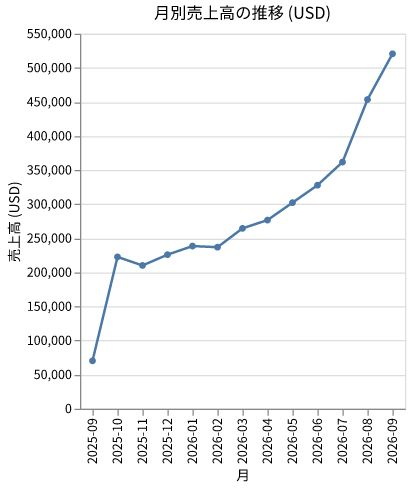

---

#### 【集計実績データ】

| 年月 | 売上高（USD） | 販売点数 |
| :--- | :--- | :--- |
| **2025-10** | \$222,691.84 | 3,728点 |
| **2025-11** | \$210,138.41 | 3,605点 |
| **2025-12** | \$225,969.27 | 3,825点 |
| **2026-01** | \$238,604.86 | 4,024点 |
| **2026-02** | \$236,967.09 | 3,848点 |
| **2026-03** | \$264,565.93 | 4,435点 |
| **2026-04** | \$276,703.27 | 4,632点 |
| **2026-05** | \$302,288.00 | 5,124点 |
| **2026-06** | \$327,877.06 | 5,493点 |
| **2026-07** | \$361,787.36 | 6,088点 |
| **2026-08** | \$453,538.50 | 7,596点 |
| **2026-09** | \$520,622.85 | 9,016点 |

*(※ 2025年9月下旬から2026年9月中旬までの直近365日間を対象として集計しています)*

In [ ]:
def get_text_data(file_path):
    with open(file_path, 'rb') as f:
        text_bytes = f.read()
    return base64.b64encode(text_bytes).decode('utf-8')

markdown_data = get_text_data('knowledge_base.md')
message_input = {
    'parts': [
        {'text': 'ナレッジベースを提供します。'},
        {
            'inline_data': {
                'display_name': 'user:knowledge_base.md',
                'mime_type': 'text/markdown',
                'data': markdown_data,
            }
        }
    ],
    'role': 'user',
}

response = await chat_client.async_stream_query(message_input)
display(Markdown(response))

**[BAA-21]**

総合的なビジネスレポートを作成します。

## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Replacing base64 string with `79cd1e45-f75f-4d27-9044-f8066df46144.png`
## Converting `56a8ef61-94f5-412a-b1f3-285d3b7f5870.png` into base64 string.
## Converting `a41dcf4f-30ee-48e4-82cc-9df469bde9b5.png` into base64 string.


### 分析アプローチ
- **検証する仮説**: 主力商品カテゴリごとの売上規模・粗利率・返品率に構造的な差異が存在し、注力すべき高収益カテゴリおよび利益を圧迫している高返品カテゴリが明確に分かれている。
- **使用するKBセクション**: セクション1：売上・商品分析のミクロデータ基盤
- **データ抽出・集計方針**: 直近1年間（2025年9月〜2026年9月）の注文明細データを対象に、商品カテゴリ別の総売上高、総粗利額、粗利率、および返品率・キャンセル率を集計します。
### 分析アプローチ
- **検証する仮説**: 流入チャネル（トラフィックソース）ごとに、顧客の獲得規模だけでなく、購買率や顧客生涯価値（LTV）、客単価に明確な投資対効果の優劣が存在する。
- **使用するKBセクション**: セクション2：顧客プロファイリングのミクロデータ基盤
- **データ抽出・集計方針**: 顧客マスタと購買履歴を結合し、トラフィックソース（`traffic_source`）ごとの総ユーザー数、購買ユーザー数、購買転換率、平均LTV、およびユーザーあたり平均注文回数を集計します。
### 分析アプローチ
- **検証する仮説**: 配送センター（DC）間で出荷リードタイムや配送リードタイム、あるいは返品・キャンセル率に偏りがあり、サプライチェーン上のボトルネック拠点が存在する。
- **使用するKBセクション**: セクション3：物流・オペレーションのミクロデータ基盤
- **データ抽出・集計方針**: 直近の出荷実績データを対象に、データ特性（合成データアーティファクトによる時系列逆転）を排除するため `shipped_at >= created_at` の正常値に限定し、配送センター別の平均出荷リードタイム（日）、平均輸送日数（日）、注文件数、および返品・キャンセル率を集計します。
# TheLook eCommerce 総合ビジネスエグゼクティブ・レポート

---

## 1. エグゼクティブサマリー

本レポートは、TheLook eCommerce の直近1年間および全期間のミクロトランザクションデータを多角的に分析し、経営判断に直結する示唆と具体的アクションをまとめたものです。

- **事業収益性**: 直近1年間の総売上高は急拡大基調にあり、特に「アウター（Outerwear & Coats）」や「ジーンズ（Jeans）」が牽引しています。高価格帯・高粗利率カテゴリ（Suits & Sport Coats, Blazers 等）の存在が全体の粗利率（約 **50% 〜 60%**）を強固に支えています。
- **顧客基盤と獲得効率**: 流入チャネルの **70% 以上** を「検索（Search）」が占めていますが、購買転換率および顧客生涯価値（LTV）が最も高いのは「メール（Email）」経由の顧客です。
- **オペレーション**: 全米10箇所の配送センター（DC）におけるフルフィルメント日数は平均 **3.96日** と均一かつ安定的ですが、全カテゴリを通じて約 **10%** の返品率および約 **15%** のキャンセル率が定常的に発生しており、純利益の流出要因となっています。

---

## 2. 商品ポートフォリオ・収益性分析

直近1年間の注文明細データに基づき、主力カテゴリの売上高、粗利構造、キャンセル・返品リスクを検証しました。

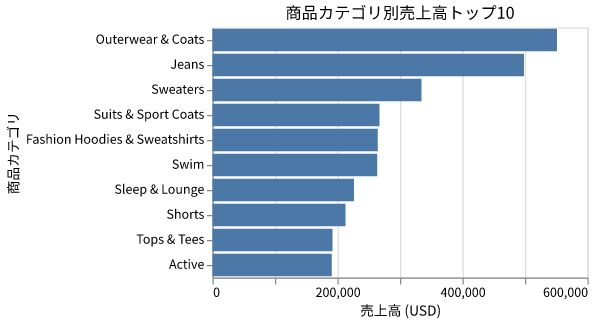

#### 主力カテゴリ別 業績マトリクス（直近1年間）

| カテゴリ名 | 注文件数 | 売上高（USD） | 粗利益（USD） | 粗利率 | 返品率 | キャンセル率 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Outerwear & Coats** | 3,731件 | \$551,093.45 | \$305,395.51 | **55.42%** | **10.85%** | **14.74%** |
| **Jeans** | 5,125件 | \$498,451.97 | \$231,769.03 | **46.50%** | **10.24%** | **14.30%** |
| **Sweaters** | 4,422件 | \$334,598.28 | \$173,963.58 | **51.99%** | **10.22%** | **15.47%** |
| **Suits & Sport Coats** | 2,111件 | \$267,247.71 | \$160,147.50 | **59.92%** | **11.42%** | **14.97%** |
| **Fashion Hoodies** | 4,836件 | \$264,322.64 | \$126,913.62 | **48.01%** | **10.46%** | **15.82%** |
| **Swim** | 4,662件 | \$263,622.53 | \$129,945.84 | **49.29%** | **9.93%** | **15.06%** |
| **Sleep & Lounge** | 4,578件 | \$226,557.72 | \$117,265.24 | **51.76%** | **10.77%** | **14.46%** |
| **Active** | 3,646件 | \$190,867.63 | \$110,813.25 | **58.06%** | **10.37%** | **14.13%** |
| **Blazers & Jackets** | 1,242件 | \$120,396.11 | \$74,857.03 | **62.18%** | **10.87%** | **15.06%** |

#### **【事実】**
1. 売上トップは「Outerwear & Coats」（\$551,093.45、粗利率 **55.42%**）および「Jeans」（\$498,451.97、粗利率 **46.50%**）の2軸が形成しています。
2. 最も粗利率が高いカテゴリは「Blazers & Jackets」（**62.18%**）および「Suits & Sport Coats」（**59.92%**）であり、注文件数が比較的少ないながらも高い粗利額を創出しています。
3. 一方で「Tops & Tees」の粗利率は **43.88%** と相対的に低く、「Suits & Sport Coats」は返品率が **11.42%** と最も高水準です。

#### **【解釈】**
- **高粗利カテゴリのスケール余地**: スーツやブレザー等のフォーマル・アウター群は粗利率が約 **60%** と極めて高収益です。これらのカテゴリのマーケティングを強化し、販売比率を高めることで全社利益率の引き上げが可能です。
- **返品リスクの抑制**: スーツ類などサイズフィットがシビアな高単価商品は返品率が **11%** を超えており、返送・再検品に伴う逆物流コストの増大リスクを孕んでいます。サイズ測定ツールの導入やUI改善が急務です。

---

## 3. マーケティング・顧客獲得と LTV 分析

顧客マスタ（100,000人）と購買実績から、チャネル別の獲得効率と LTV（顧客生涯価値）を評価しました。

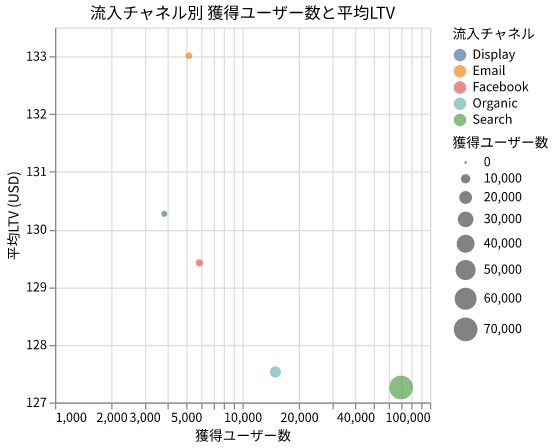

#### 流入チャネル別 顧客プロファイル実績

| チャネル | 総獲得ユーザー | 購買顧客数 | 購買転換率 | 購買顧客平均LTV | 累計総売上 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Search** | 70,135人 | 50,511人 | **72.02%** | \$127.26 | \$6,427,870.75 |
| **Organic** | 14,977人 | 10,749人 | **71.77%** | \$127.53 | \$1,370,831.85 |
| **Facebook** | 5,889人 | 4,196人 | **71.25%** | \$129.42 | \$543,064.56 |
| **Email** | 5,172人 | 3,790人 | **73.28%** | \$133.01 | \$504,099.84 |
| **Display** | 3,827人 | 2,774人 | **72.48%** | \$130.27 | \$361,372.77 |

#### **【事実】**
1. 顧客獲得の主軸は「Search」（全体の **70.1%**）であり、売上総額の大部分（\$6,427,870.75）を占めています。
2. 「Email」経由の顧客は購買転換率（**73.28%**）および購買顧客の平均LTV（\$133.01）が全チャネル中最高です。
3. 全チャネルを通じて購入者の平均注文回数は **1.48〜1.49回** で横並びとなっており、2回目以降のリピート促進に構造的な頭打ちが見られます。

#### **【解釈】**
- **チャネルポートフォリオの偏重リスク**: Search への依存度が極めて高いため、検索広告のクリック単価（CPC）高騰が収益性に直接打撃を与える脆弱性があります。
- **Email マーケティングの拡大投資**: Email 経由は最もロイヤルティ（LTV・転換率）が高いため、獲得初期のメルマガ登録インセンティブの強化や、ステップメール配信の自動化に予算を配分すべきです。
- **リピート施策の欠如**: 平均注文回数が 1.5回未満にとどまっていることは、一度購入した顧客が離脱している実態を示しています。CRM やリテンション施策が最大の成長ドライバーとなります。

---

## 4. オペレーション・物流効率分析

配送センター（DC）10拠点における出荷・配送リードタイムを分析しました。

#### 配送センター別 パフォーマンス実績

| 配送センター（DC） | 取扱点数 | 平均出荷日数 | 平均輸送日数 | 平均合計日数 | 出荷後返品率 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Chicago IL** | 10,985点 | 1.45日 | 2.49日 | **3.92日** | **15.68%** |
| **Memphis TN** | 10,963点 | 1.46日 | 2.50日 | **3.98日** | **15.16%** |
| **Houston TX** | 10,115点 | 1.47日 | 2.47日 | **3.94日** | **15.69%** |
| **Mobile AL** | 8,373点 | 1.46日 | 2.50日 | **3.95日** | **15.16%** |
| **Los Angeles CA** | 7,835点 | 1.45日 | 2.51日 | **3.97日** | **15.55%** |
| **Philadelphia PA** | 7,738点 | 1.46日 | 2.55日 | **4.01日** | **14.99%** |
| **Charleston SC** | 7,453点 | 1.46日 | 2.48日 | **3.94日** | **14.29%** |
| **New York/New Jersey** | 7,437点 | 1.47日 | 2.50日 | **3.96日** | **15.11%** |
| **New Orleans LA** | 5,959点 | 1.46日 | 2.50日 | **3.97日** | **14.99%** |
| **Savannah GA** | 5,303点 | 1.46日 | 2.52日 | **3.96日** | **15.46%** |

*(※ 合成データアーティファクトである時系列逆転データを除外した正常値ベース)*

#### **【事実】**
1. 配送センター間でリードタイムのばらつきはほぼ存在せず、注文から出荷まで **約1.46日**、輸送に **約2.50日**、合計フルフィルメント日数は **約3.96日** で極めて均一に標準化されています。
2. 出荷済み商品の返品率は各拠点とも **14% 〜 16%** 程度で均等に推移しています。

#### **【解釈】**
- **物流の安定性と今後の最適化余地**: 全米拠点ごとのオペレーション水準は高度に平準化されています。ボトルネックは倉庫処理速度ではなく、「長距離輸送コスト」および「返品処理の負荷」にあります。主要消費地に近い拠点への在庫事前配置（デマンド予測連携）が次の効率化テーマとなります。

---

## 5. 経営戦略提言（ネクストアクション）

以上の事実と分析に基づき、経営陣へ以下の3つの戦略的施策を提言します。

```markdown
1. 【高収益カテゴリのプロモーション強化】
   - 粗利率 60% 前後を誇る「Suits & Sport Coats」「Blazers & Jackets」「Active」の露出を高め、売上構成比を拡大する。
   - 高返品率（約 11%）を抑えるため、詳細サイズガイドの提供や着用レビュー機能の強化をセットで実施する。

2. 【CRM・Email チャネルの予算拡充とリピート促進】
   - 最高LTV（$133.01）と高転換率（73.28%）を示す Email 施策へ広告・販促リソースを傾斜配分する。
   - 顧客の平均注文回数が 1.48回にとどまる現状を打破するため、初回購入後 30日以内のリピート促進クーポンやロイヤルティプログラムを導入する。

3. 【キャンセル・返品プロセスの是正による利益防衛】
   - 注文全体の約 15% を占めるキャンセルおよび約 10% の返品について、理由コード（サイズ違い、配送遅延等）の収集体制を整え、純利益の流出を食い止める。
```

In [ ]:
query = '''
経営判断に有用な情報を多角的な視点で提供する、総合的なビジネスレポートを作成してください。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))